In [1]:
# ============================================================
# CELL 1: Import & Setup
# ============================================================
import os, random, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('outputs', exist_ok=True)

In [2]:
# ============================================================
# CELL 2: Load dữ liệu
# ============================================================
amzn = np.load('data/amzn_processed.npz')
retail = np.load('data/retail_processed.npz')

X_train_a, y_train_a = amzn['X_train'], amzn['y_train']
X_val_a,   y_val_a   = amzn['X_val'],   amzn['y_val']
X_test_a,  y_test_a  = amzn['X_test'],  amzn['y_test']
y_min_a, y_range_a = amzn['y_mean'][0], amzn['y_scale'][0]

X_train_r, y_train_r = retail['X_train'], retail['y_train']
X_val_r,   y_val_r   = retail['X_val'],   retail['y_val']
X_test_r,  y_test_r  = retail['X_test'],  retail['y_test']

print("Amazon:", X_train_a.shape)
print("Retail:", X_train_r.shape)

Amazon: (4648, 30, 5)
Retail: (395001, 10, 4)


In [3]:
# ============================================================
# CELL 3: Keras AMZN Regression
# ============================================================
def build_keras_regressor(input_shape, hidden=64, dropout=0.2):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.SimpleRNN(hidden, activation='tanh', return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='mse', metrics=['mae'])
    return model

keras_amzn = build_keras_regressor((X_train_a.shape[1], X_train_a.shape[2]))
keras_amzn.summary()

t0 = time.time()
history = keras_amzn.fit(
    X_train_a, y_train_a,
    validation_data=(X_val_a, y_val_a),
    epochs=60, batch_size=32, verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                       restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=5, min_lr=1e-6)
    ]
)
keras_time = time.time() - t0
print(f"Keras AMZN - Training time: {keras_time:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

Keras AMZN - Training time: 27.77s


Keras AMZN Test: MAE=1.9420 | RMSE=2.0892 | R2=-5.7103 | MAPE=45.71%


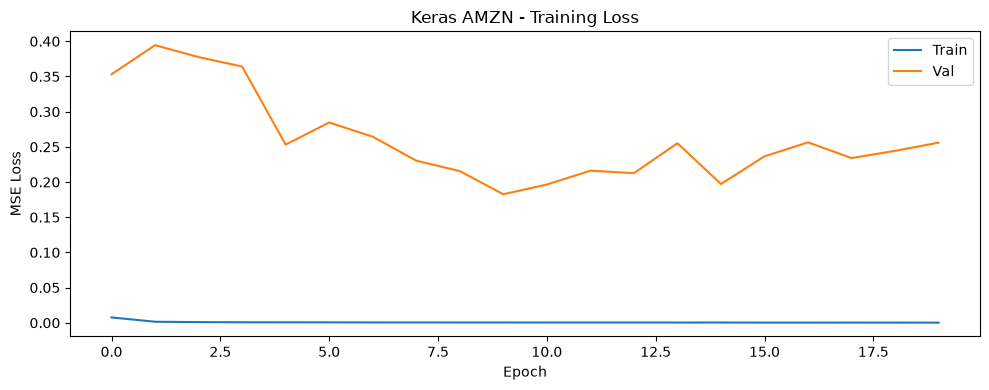

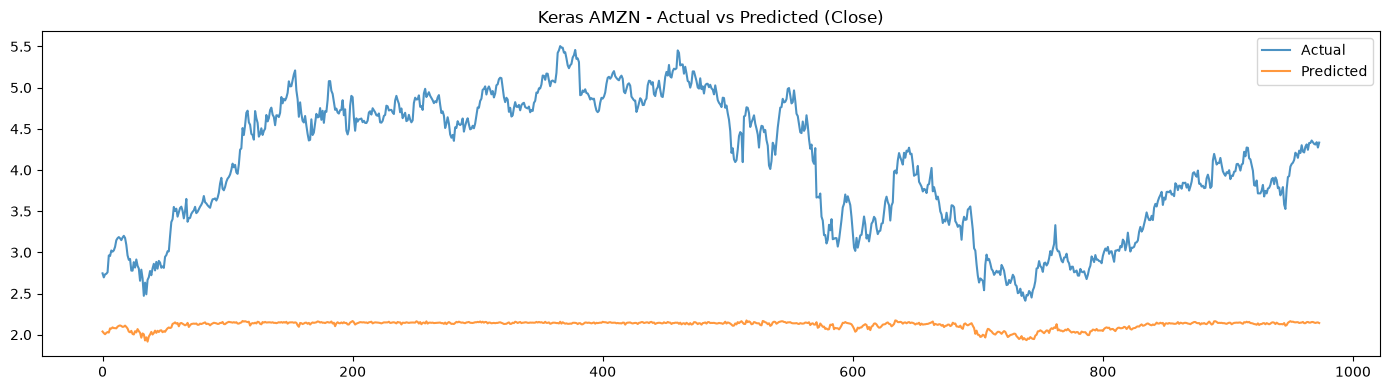

In [4]:
# ============================================================
# CELL 4: Đánh giá Keras AMZN
# ============================================================
pred_test_k = keras_amzn.predict(X_test_a, verbose=0).ravel()
pred_test_k_real = pred_test_k * y_range_a + y_min_a
y_test_real      = y_test_a * y_range_a + y_min_a

mae = mean_absolute_error(y_test_real, pred_test_k_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_test_k_real))
r2 = r2_score(y_test_real, pred_test_k_real)
mape = np.mean(np.abs((y_test_real - pred_test_k_real) / y_test_real)) * 100

print(f"Keras AMZN Test: MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | MAPE={mape:.2f}%")

keras_amzn_metrics = {'MAE': float(mae), 'RMSE': float(rmse),
                      'R2': float(r2), 'MAPE': float(mape),
                      'time': keras_time,
                      'best_val': float(min(history.history['val_loss']))}

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Keras AMZN - Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()
plt.tight_layout()
plt.savefig('outputs/03_keras_amzn_loss.png', dpi=200)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(y_test_real, label='Actual', alpha=0.8)
plt.plot(pred_test_k_real, label='Predicted', alpha=0.8)
plt.title('Keras AMZN - Actual vs Predicted (Close)')
plt.legend(); plt.tight_layout()
plt.savefig('outputs/03_keras_amzn_pred.png', dpi=200)
plt.show()

In [5]:
# ============================================================
# CELL 5: Keras Retail Classification
# ============================================================
def build_keras_classifier(input_shape, hidden=64, dropout=0.2):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.SimpleRNN(hidden, activation='tanh', return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

keras_retail = build_keras_classifier((X_train_r.shape[1], X_train_r.shape[2]))
keras_retail.summary()

# Class weights xử lý imbalance
pos = y_train_r.sum(); neg = len(y_train_r) - pos
class_weight = {0: 1.0, 1: float(neg / max(pos, 1))}
print("Class weight:", class_weight)

t0 = time.time()
history_r = keras_retail.fit(
    X_train_r, y_train_r,
    validation_data=(X_val_r, y_val_r),
    epochs=30, batch_size=64, verbose=0,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                       restore_best_weights=True)
    ]
)
keras_time_r = time.time() - t0
print(f"Keras Retail - Training time: {keras_time_r:.2f}s")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │           4,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Class weight: {0: 1.0, 1: 18.442852020263672}
Keras Retail - Training time: 856.21s


Keras Retail Test:
  Acc=0.7499 | Prec=0.1170 | Rec=0.5898 | F1=0.1953 | AUC=0.6991
              precision    recall  f1-score   support

         0.0     0.9715    0.7586    0.8520     80290
         1.0     0.1170    0.5898    0.1953      4354

    accuracy                         0.7499     84644
   macro avg     0.5443    0.6742    0.5236     84644
weighted avg     0.9276    0.7499    0.8182     84644



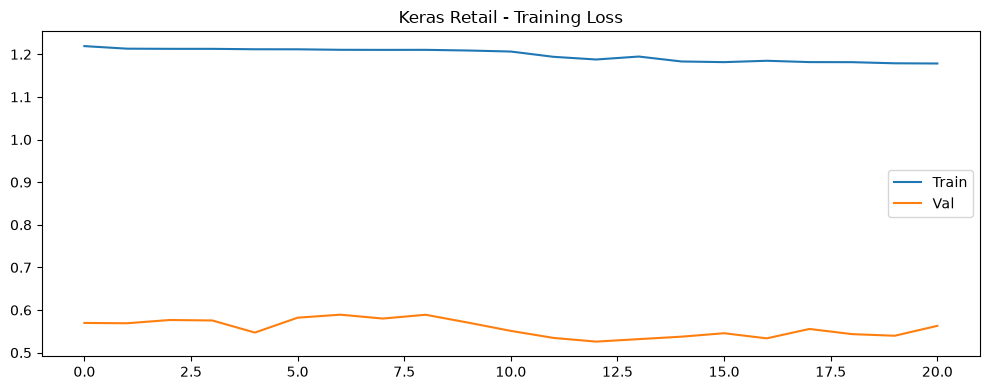

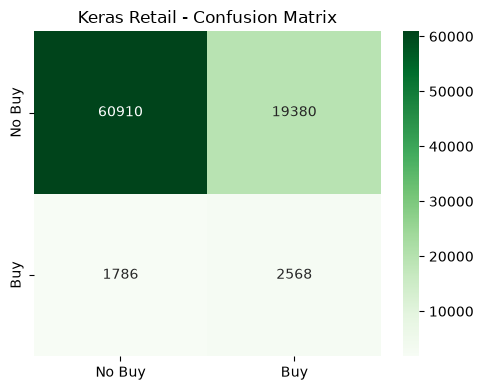

In [6]:
# ============================================================
# CELL 6: Đánh giá Keras Retail
# ============================================================
probs_k = keras_retail.predict(X_test_r, verbose=0).ravel()
preds_k = (probs_k >= 0.5).astype(int)

acc = accuracy_score(y_test_r, preds_k)
prec = precision_score(y_test_r, preds_k, zero_division=0)
rec = recall_score(y_test_r, preds_k, zero_division=0)
f1 = f1_score(y_test_r, preds_k, zero_division=0)
auc = roc_auc_score(y_test_r, probs_k)
cm = confusion_matrix(y_test_r, preds_k)

print(f"Keras Retail Test:")
print(f"  Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
print(classification_report(y_test_r, preds_k, digits=4, zero_division=0))

keras_retail_metrics = {'accuracy': float(acc), 'precision': float(prec),
                        'recall': float(rec), 'f1': float(f1), 'auc': float(auc),
                        'time': keras_time_r,
                        'best_val': float(min(history_r.history['val_loss']))}

plt.figure(figsize=(10, 4))
plt.plot(history_r.history['loss'], label='Train')
plt.plot(history_r.history['val_loss'], label='Val')
plt.title('Keras Retail - Training Loss')
plt.legend(); plt.tight_layout()
plt.savefig('outputs/03_keras_retail_loss.png', dpi=200)
plt.show()

plt.figure(figsize=(5, 4))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Buy', 'Buy'], yticklabels=['No Buy', 'Buy'])
plt.title('Keras Retail - Confusion Matrix')
plt.tight_layout()
plt.savefig('outputs/03_keras_retail_cm.png', dpi=200)
plt.show()

In [8]:
# ============================================================
# CELL 7: Lưu kết quả Keras
# ============================================================
results_k = {
    'amzn': keras_amzn_metrics,
    'retail': keras_retail_metrics,
    'hist_amzn': {k: [float(x) for x in v] for k, v in history.history.items()},
    'hist_retail': {k: [float(x) for x in v] for k, v in history_r.history.items()},
    'pred_amzn': pred_test_k_real.tolist(),
    'y_amzn': y_test_real.tolist(),
    'pred_retail': probs_k.tolist(),
    'y_retail': y_test_r.tolist(),
}
with open('outputs/keras_results.json', 'w') as f:
    json.dump(results_k, f, indent=2)
print("Đã lưu outputs/keras_results.json")

Đã lưu outputs/keras_results.json
